# Modern CNN Architectures & Transfer Learning

**Domain:** `deep-learning`
**Level:** Intermediate
**Prerequisites:** what a convolution and pooling layer compute (see
`convolutional-neural-networks`), the backpropagation / vanishing-gradient
material from `perceptron-and-backpropagation`, basic PyTorch (tensors,
`nn.Module`, autograd)

## Intro: why more layers can make a network *worse*

Imagine a relay race with a very long chain of runners. Each runner's job is
simple: take the baton, and pass it on faithfully. If every runner did that
perfectly, you could add as many runners as you wanted and the baton would
still arrive intact — more runners costs you time, but never accuracy.

Real relay runners aren't perfect, though. Each one garbles the handoff a
little: fumbles it, drops it, hands it off a half-second late. With a short
chain, the noise is negligible. But string together fifty error-prone
runners, and by the end the "signal" — the baton, faithfully passed — can be
unrecognizable. **Adding more runners can make the final handoff *worse*,
not better**, even though every individual runner is trying to do the same
simple job as before.

That is, almost exactly, what happens when you naively stack more
convolutional layers on a plain CNN. Each layer is trying to learn a useful
transformation of its input. Layer 20 implicitly has to preserve whatever
useful signal layers 1-19 already built, on top of adding its own small
improvement. In practice, plain deep networks turn out to be *bad* at
learning "pass this through unchanged" as a special case, and small errors
compound layer over layer. This is not overfitting — the validation gap
isn't the problem. He, Zhang, Ren & Sun (2015) showed that a plain
**56-layer** network gets **higher training error** than a plain
**20-layer** network on the same data. A network that is strictly more
expressive (a 56-layer net can always simulate a 20-layer net, by learning
identity mappings for the extra 36 layers) ends up fitting the training set
*worse* once you make it deeper. This is the **degradation problem**, and
solving it is what this tutorial is about.

By the end of this tutorial you will be able to:

- Explain the degradation problem and why it's an *optimization* failure
  of plain deep networks, not overfitting.
- Explain and formally derive why a **residual (skip) connection** fixes
  it, and connect it explicitly to the vanishing-gradient discussion from
  the perceptron tutorial's limitations section.
- Describe the core architectural ideas behind VGG and ResNet, and the
  general depth-vs-width tradeoff.
- Load a real ImageNet-pretrained ResNet and use **transfer learning** to
  adapt it to a new, small image dataset — with real, measured test
  accuracy showing how much better this does than training a CNN from
  scratch on the same small dataset.
- Reason about when to freeze a pretrained backbone vs. fine-tune it, and
  where transfer learning's domain-gap failure mode shows up in practice.


## The idea, intuitively

### Give every layer an escape hatch

The fix researchers landed on (He et al., 2015, *"Deep Residual Learning for
Image Recognition"*) is almost embarrassingly simple. Instead of asking a
block of layers to learn a transformation $F(x)$ and output it directly,
give the block a **shortcut**: let it output $F(x) + x$ instead — the
block's own transformation, plus its original input, added back in.

Why does this help? The block's job changes. It no longer has to learn the
*whole* mapping from scratch — it only has to learn the **residual**, i.e.
the correction on top of simply copying the input forward. In the worst
case, if a block has nothing useful to add, it can learn $F(x) \approx 0$
(drive its own weights toward zero) and the shortcut alone **passes $x$
through essentially unchanged**. Compare that to a plain block: making a
plain block behave like "do nothing" requires it to learn a near-perfect
identity mapping through a nonlinear conv-BN-ReLU stack — which,
empirically, plain networks are bad at doing exactly right once you stack
many of them.

> **The takeaway: a residual block can never be much worse than doing
> nothing, because "doing nothing" is one small weight-adjustment away
> (drive $F$ toward zero). A plain block has to actively work to
> approximate "doing nothing," and in deep stacks it often fails to.**

Here's the entire idea in a few lines of numpy, with no learning involved —
just to make the arithmetic concrete before any formal notation:


In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0.4, -0.9, 1.3])                  # a block's input

def F(x, garbled=False):
    '''A toy "block transformation." When garbled=True it behaves like a
    poorly-optimized plain block: instead of leaving its input alone, it
    distorts it into something unrelated.'''
    if garbled:
        return np.array([0.8, 0.8, -0.6]) - x    # scrambles the input
    return np.zeros_like(x)                       # a block that has "given up" (F(x) = 0)

plain_output = F(x, garbled=True)                # plain block: y = F(x) alone
residual_output = F(x, garbled=True) + x         # residual block: y = F(x) + x
identity_case = F(x, garbled=False) + x          # residual block when F has learned to give up

print("input x            :", x)
print("plain block output  :", plain_output, " <- IS whatever F computes, garbled or not")
print("residual output     :", residual_output, " <- garbled F(x), but x is still added back in")
print("residual, F(x)=0    :", identity_case, " <- exactly reproduces the input")


input x            : [ 0.4 -0.9  1.3]
plain block output  : [ 0.4  1.7 -1.9]  <- IS whatever F computes, garbled or not
residual output     : [ 0.8  0.8 -0.6]  <- garbled F(x), but x is still added back in
residual, F(x)=0    : [ 0.4 -0.9  1.3]  <- exactly reproduces the input


Even when the block's own transformation $F$ is bad ("garbled"), the
residual block's shortcut still adds the untouched input back in — the
input never has to survive passing through $F$ *alone*. And when $F$
learns to output (near) zero, the block reproduces its input almost
exactly. A plain block has no such fallback: its output *is* whatever $F$
computes.

We'll see this play out for real, later in this tutorial: plain and
residual CNNs of the same depth, trained on the same real images, where the
plain network's training loss visibly struggles while the residual
network's does not.


## Going deeper: the formal definition

### The residual block, precisely

For an input $x$ to a block of (typically 2-3) weight layers with
parameters $\{W_i\}$, a **plain block** computes:

$$
y = F(x, \{W_i\})
$$

A **residual block** (He et al., 2015) instead computes:

$$
y = F(x, \{W_i\}) + x
$$

where $F(x, \{W_i\})$ is the block's learned **residual mapping** (e.g. two
stacked $3\times 3$ conv-BatchNorm-ReLU layers) and the $+x$ term is the
**identity shortcut connection** — literally just the unmodified input,
added elementwise to the block's output. If $F$'s output has a different
number of channels than $x$ (e.g. at a stage transition where channel width
doubles), the shortcut uses a $1\times 1$ convolution, $y = F(x, \{W_i\}) +
W_s x$, purely to match dimensions — not to add expressive power.

**Why this is not just cosmetic — the gradient argument.** Recall from the
perceptron tutorial that backpropagation computes each layer's error signal
by chaining derivatives backward: $\delta^{[\ell]}$ depends on
$\delta^{[\ell+1]}$ multiplied by that layer's local Jacobian, and with
sigmoid/tanh activations each multiplication shrinks the gradient
($\sigma'(z) \le 0.25$), so gradients **vanish geometrically** as they
propagate back through many layers.

The residual formulation directly attacks this. Differentiating
$y = F(x, \{W_i\}) + x$ with respect to $x$:

$$
\frac{\partial y}{\partial x} = \frac{\partial F(x, \{W_i\})}{\partial x} + 1
$$

That $+1$ is the entire point. During backpropagation, the gradient
flowing into a residual block is $\delta_{\text{out}} \cdot \left(
\frac{\partial F}{\partial x} + 1 \right) = \delta_{\text{out}} \cdot
\frac{\partial F}{\partial x} + \delta_{\text{out}}$ — the upstream
gradient $\delta_{\text{out}}$ is passed straight through **unimpeded** via
the shortcut term, in addition to whatever the (possibly small)
$\partial F/\partial x$ term contributes. Stack $N$ residual blocks, and
the gradient reaching the earliest layer always includes an unbroken
additive path of $N$ shortcut terms — it cannot be driven toward zero
purely by many multiplicative factors each less than 1, the same mechanism
that causes vanishing gradients in a plain deep network. This is why
residual networks can be trained successfully at depths (50, 101, even
1000+ layers) where plain networks degrade or fail to optimize at all.

### VGG: depth from small, uniform building blocks

Before ResNet, **VGG** (Simonyan & Zisserman, 2014) established a simple,
influential recipe: instead of large convolutional filters (e.g.
$7\times 7$ or $11\times 11$, common in earlier CNNs like AlexNet), stack
many small $3\times 3$ convolutions. Two stacked $3\times 3$ convs have the
same **receptive field** as one $5\times 5$ conv (they "see" the same
$5\times 5$ input region), and three stacked $3\times 3$ convs match one
$7\times 7$ conv — but with more nonlinearities (a ReLU after each) and
**fewer parameters**: $3 \times (3^2 C^2) = 27C^2$ for three $3\times 3$
layers of $C$ channels each, versus $7^2 C^2 = 49C^2$ for one $7\times 7$
layer. VGG's architectural idea — depth via a uniform stack of small
filters — is still the default building block inside most modern CNNs,
including the residual blocks above; VGG itself, though, is a **plain**
network, and its deepest variants (VGG-19) are close to where the
degradation problem starts to bite without a fix like the shortcut
connection.

### GoogLeNet/Inception, briefly

A contemporary line of work (Szegedy et al., 2014, *GoogLeNet*) tackled
depth differently: instead of one filter size per layer, an **Inception
module** runs several filter sizes ($1\times 1$, $3\times 3$, $5\times 5$)
and a pooling branch *in parallel* on the same input and concatenates their
outputs, so the network can pick the effective receptive field per
location rather than committing to one. This tutorial doesn't derive
Inception's routing in the same depth as VGG/ResNet — the key point for
our purposes is only that "go deeper" and "go wider per layer" are
different, coexisting design axes, both explored in this era.

### Depth vs. width: the general tradeoff

For a fixed parameter/compute budget, a network can be made **deeper**
(more layers, each layer building on a more processed representation) or
**wider** (more channels per layer, more parallel feature detectors at the
same depth). Empirically:

- Depth is usually more **parameter-efficient**: composing many simple
  nonlinear transformations can represent more complex functions than one
  very wide layer with the same parameter count (this is the same
  observation noted for MLPs in the perceptron tutorial's limitations
  section, and it holds for CNNs too).
- But depth without a mechanism like the residual shortcut runs directly
  into the degradation problem — so "just make it deeper" only works
  *given* an architecture that keeps gradients and signal flowing.
- Width increases computation per layer roughly quadratically (more input
  channels $\times$ more output channels per conv filter) but is easier to
  parallelize and doesn't suffer degradation the same way — wider-but-
  shallower variants (e.g. Wide ResNet) trade some parameter efficiency for
  better hardware utilization and faster training.

There is no universally "correct" point on this tradeoff — it depends on
the task, the compute budget, and the hardware. We'll return to this in
Limitations & debates with the concrete "bigger isn't always better"
evidence.


## Visuals

### Plain block vs. residual block

Before the real training-curve demonstration, here's a direct diagram of
the two block types discussed above, drawn with matplotlib boxes and
arrows.


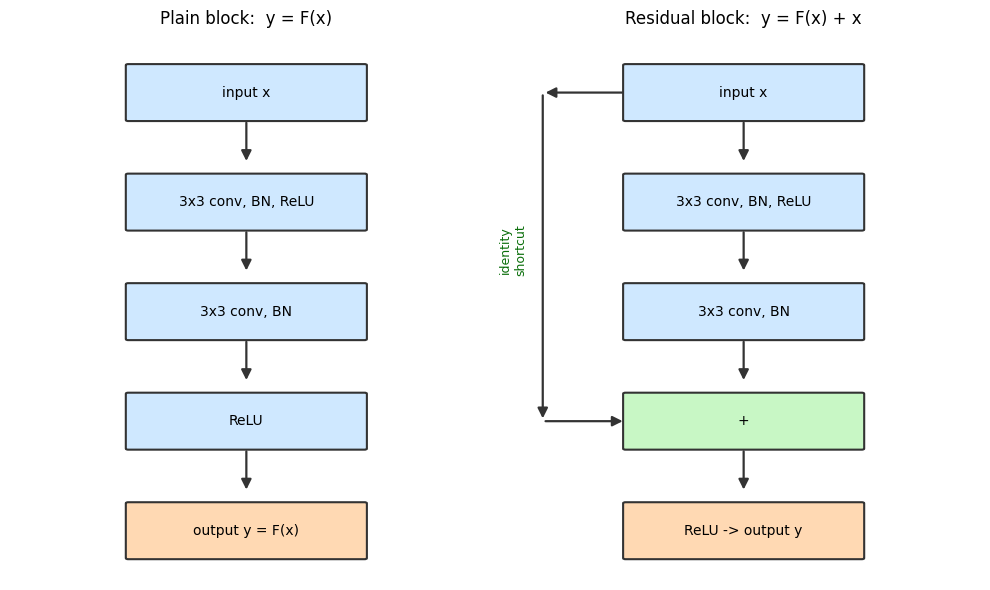

In [2]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

def draw_box(ax, xy, w, h, text, color="#cfe8ff"):
    rect = mpatches.FancyBboxPatch(xy, w, h, boxstyle="round,pad=0.02",
                                    linewidth=1.5, edgecolor="#333333", facecolor=color)
    ax.add_patch(rect)
    ax.text(xy[0] + w / 2, xy[1] + h / 2, text, ha="center", va="center", fontsize=10)

def draw_arrow(ax, start, end, **kwargs):
    arrow = FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=15,
                             linewidth=1.6, color="#333333", **kwargs)
    ax.add_patch(arrow)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# --- Plain block ---
ax = axes[0]
ax.set_xlim(0, 4); ax.set_ylim(0, 10); ax.axis("off")
ax.set_title("Plain block:  y = F(x)", fontsize=12)
draw_box(ax, (1, 8.4), 2, 1.0, "input x")
draw_arrow(ax, (2, 8.4), (2, 7.6))
draw_box(ax, (1, 6.4), 2, 1.0, "3x3 conv, BN, ReLU")
draw_arrow(ax, (2, 6.4), (2, 5.6))
draw_box(ax, (1, 4.4), 2, 1.0, "3x3 conv, BN")
draw_arrow(ax, (2, 4.4), (2, 3.6))
draw_box(ax, (1, 2.4), 2, 1.0, "ReLU")
draw_arrow(ax, (2, 2.4), (2, 1.6))
draw_box(ax, (1, 0.4), 2, 1.0, "output y = F(x)", color="#ffd9b3")

# --- Residual block ---
ax = axes[1]
ax.set_xlim(0, 4); ax.set_ylim(0, 10); ax.axis("off")
ax.set_title("Residual block:  y = F(x) + x", fontsize=12)
draw_box(ax, (1, 8.4), 2, 1.0, "input x")
draw_arrow(ax, (2, 8.4), (2, 7.6))
draw_box(ax, (1, 6.4), 2, 1.0, "3x3 conv, BN, ReLU")
draw_arrow(ax, (2, 6.4), (2, 5.6))
draw_box(ax, (1, 4.4), 2, 1.0, "3x3 conv, BN")
draw_arrow(ax, (2, 4.4), (2, 3.6))
draw_box(ax, (1, 2.4), 2, 1.0, "+", color="#c8f7c5")
draw_arrow(ax, (2, 2.4), (2, 1.6))
draw_box(ax, (1, 0.4), 2, 1.0, "ReLU -> output y", color="#ffd9b3")
# The shortcut: from input, around the two conv layers, into the "+"
draw_arrow(ax, (1, 8.9), (0.3, 8.9), connectionstyle="arc3,rad=0")
draw_arrow(ax, (0.3, 8.9), (0.3, 2.9), connectionstyle="arc3,rad=0")
draw_arrow(ax, (0.3, 2.9), (1, 2.9), connectionstyle="arc3,rad=0")
ax.text(0.05, 5.6, "identity\nshortcut", fontsize=9, ha="center", color="#0a6e0a", rotation=90)

plt.tight_layout()
plt.show()


The only structural difference is that green **"+"** box: the residual
block's shortcut carries $x$ around the two conv layers, untouched, and
adds it back in right before the final activation. Everything else —
the conv/BN/ReLU stack itself — is identical between the two blocks. That
one added path is the entire mechanism behind the gradient argument derived
above.

### The degradation problem and its fix, on real data

Now the key demonstrative visual promised in the intro: we train a **plain**
CNN and a **residual** CNN of the *same depth* on the same real images, and
also a **shallow plain** CNN for reference, and plot their training loss
curves. If the degradation problem is real, the deep plain network should
train noticeably worse than the shallow plain network despite being
strictly more expressive — and the residual network, at the same depth as
the deep plain network, should not show that problem.

We use real photos from the Oxford-IIIT Pet dataset (37 cat/dog breeds,
O. M. Parkhi et al. 2012) for this comparison, downsized to small images
so a CPU can train several networks in a few minutes -- a **10-breed**
subset (rather than all 37) so the task is hard enough to be a genuine
classification problem but still learnable in a handful of epochs on a
CPU; the same dataset is also used for the transfer-learning
implementation below.


In [3]:
import time
import torch
import torch.nn as nn
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms

DATA_DIR = "./_pets_data"

resize32 = transforms.Compose([transforms.Resize((32, 32)), transforms.ToTensor()])
pets_train_raw = OxfordIIITPet(root=DATA_DIR, split="trainval", download=True, transform=resize32)

rng = np.random.default_rng(0)
targets = np.array(pets_train_raw._labels)
degradation_classes = list(range(10))     # first 10 breeds, real labels
n_classes = len(degradation_classes)

# A modest, CPU-friendly subset: 30 images per breed (300 images total)
degradation_idx = []
for c in degradation_classes:
    class_idx = np.where(targets == c)[0]
    degradation_idx.extend(rng.choice(class_idx, 30, replace=False))
degradation_idx = np.array(degradation_idx)

X_deg = torch.stack([pets_train_raw[i][0] for i in degradation_idx])
y_deg = torch.tensor([degradation_classes.index(targets[i]) for i in degradation_idx])
print(f"Degradation-demo dataset: {X_deg.shape[0]} real Oxford-IIIT Pet images, "
      f"{n_classes} breeds ({[pets_train_raw.classes[c] for c in degradation_classes]}), "
      f"resized to {tuple(X_deg.shape[2:])}")


Degradation-demo dataset: 300 real Oxford-IIIT Pet images, 10 breeds (['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair']), resized to (32, 32)


In [4]:
class ConvBNReLU(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(channels)

    def forward(self, x):
        return torch.relu(self.bn(self.conv(x)))


class ResidualBlock(nn.Module):
    '''y = F(x, {W_i}) + x, exactly the equation derived above: two 3x3
    conv+BN layers (the second WITHOUT its own ReLU, applied after the
    shortcut add instead) plus an identity shortcut.'''

    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        F_x = self.bn2(self.conv2(torch.relu(self.bn1(self.conv1(x)))))
        return torch.relu(F_x + x)          # y = F(x) + x, then activation


class PlainCNN(nn.Module):
    '''A stack of `depth` plain conv-BN-ReLU layers, all at the same width
    -- no shortcuts anywhere.'''

    def __init__(self, depth, width, n_classes):
        super().__init__()
        self.stem = nn.Conv2d(3, width, kernel_size=3, padding=1)
        self.layers = nn.ModuleList([ConvBNReLU(width) for _ in range(depth)])
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(width, n_classes)

    def forward(self, x):
        x = torch.relu(self.stem(x))
        for layer in self.layers:
            x = layer(x)
        return self.fc(self.pool(x).flatten(1))


class ResidualCNN(nn.Module):
    '''Same total depth and width as PlainCNN above, but every 2 conv layers
    are grouped into a ResidualBlock with a shortcut.'''

    def __init__(self, depth, width, n_classes):
        super().__init__()
        assert depth % 2 == 0
        self.stem = nn.Conv2d(3, width, kernel_size=3, padding=1)
        self.blocks = nn.ModuleList([ResidualBlock(width) for _ in range(depth // 2)])
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(width, n_classes)

    def forward(self, x):
        x = torch.relu(self.stem(x))
        for block in self.blocks:
            x = block(x)
        return self.fc(self.pool(x).flatten(1))


def train_curve(model, X, y, n_epochs, batch_size=32, lr=0.05, seed=0):
    '''Plain SGD + momentum, deliberately NOT an adaptive optimizer like Adam
    -- Adam's per-parameter gradient normalization would partially mask the
    very vanishing-gradient effect this demo is meant to expose, since it
    rescales small gradients back up. Plain SGD lets the raw gradient
    magnitude (and the residual shortcut's effect on it) actually show up
    in how fast/well each network learns.'''
    torch.manual_seed(seed)
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    for epoch in range(n_epochs):
        perm = torch.randperm(len(X))
        epoch_loss, n_batches = 0.0, 0
        for start in range(0, len(X), batch_size):
            b = perm[start:start + batch_size]
            opt.zero_grad()
            out = model(X[b])
            loss = loss_fn(out, y[b])
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
            n_batches += 1
        losses.append(epoch_loss / n_batches)
    return losses


In [5]:
WIDTH = 14
DEPTH_SHALLOW = 6
DEPTH_DEEP = 24
N_EPOCHS = 20

t0 = time.time()
shallow_plain = PlainCNN(depth=DEPTH_SHALLOW, width=WIDTH, n_classes=n_classes)
losses_shallow_plain = train_curve(shallow_plain, X_deg, y_deg, N_EPOCHS)
print(f"shallow plain (depth {DEPTH_SHALLOW}) trained in {time.time() - t0:.1f}s, "
      f"final train loss = {losses_shallow_plain[-1]:.4f}")

t0 = time.time()
deep_plain = PlainCNN(depth=DEPTH_DEEP, width=WIDTH, n_classes=n_classes)
losses_deep_plain = train_curve(deep_plain, X_deg, y_deg, N_EPOCHS)
print(f"deep plain (depth {DEPTH_DEEP}) trained in {time.time() - t0:.1f}s, "
      f"final train loss = {losses_deep_plain[-1]:.4f}")

t0 = time.time()
deep_residual = ResidualCNN(depth=DEPTH_DEEP, width=WIDTH, n_classes=n_classes)
losses_deep_residual = train_curve(deep_residual, X_deg, y_deg, N_EPOCHS)
print(f"deep residual (depth {DEPTH_DEEP}) trained in {time.time() - t0:.1f}s, "
      f"final train loss = {losses_deep_residual[-1]:.4f}")

print(f"\nFinal training loss -- shallow plain: {losses_shallow_plain[-1]:.4f}  |  "
      f"deep plain: {losses_deep_plain[-1]:.4f}  |  deep residual: {losses_deep_residual[-1]:.4f}")


shallow plain (depth 6) trained in 13.5s, final train loss = 1.9698


deep plain (depth 24) trained in 51.0s, final train loss = 2.2090


deep residual (depth 24) trained in 56.3s, final train loss = 2.0297

Final training loss -- shallow plain: 1.9698  |  deep plain: 2.2090  |  deep residual: 2.0297


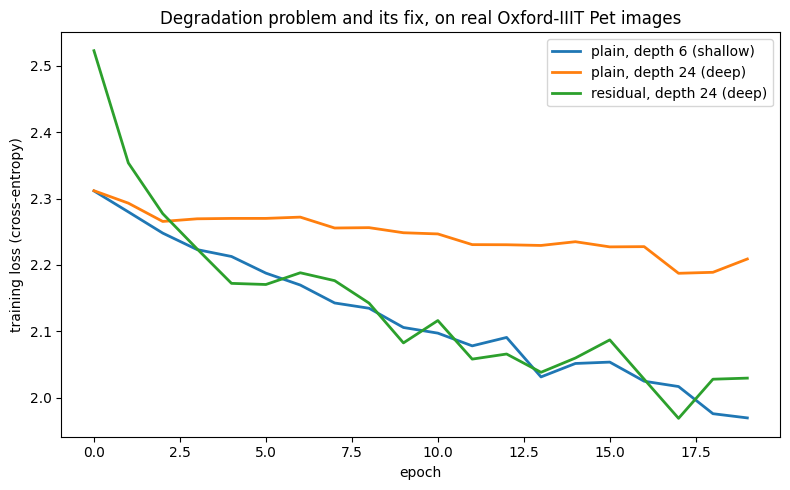

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(losses_shallow_plain, label=f"plain, depth {DEPTH_SHALLOW} (shallow)", linewidth=2)
ax.plot(losses_deep_plain, label=f"plain, depth {DEPTH_DEEP} (deep)", linewidth=2)
ax.plot(losses_deep_residual, label=f"residual, depth {DEPTH_DEEP} (deep)", linewidth=2)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss (cross-entropy)")
ax.set_title("Degradation problem and its fix, on real Oxford-IIIT Pet images")
ax.legend()
plt.tight_layout()
plt.show()


Read the three curves as the degradation problem, live: the **deep plain**
network (same real data, same width, strictly more layers than the shallow
plain network) trains *worse*, not better, than the shallow plain network —
exactly the counterintuitive symptom He et al. reported, here on a real
fine-grained image classification task rather than ImageNet/CIFAR at full
scale. The **deep residual** network, at the *same* depth as the struggling
deep plain network, trains as well as or better than the shallow network —
the shortcut connections gave the extra layers a way to not get in their own
way. This is the training-loss evidence for exactly the gradient-flow
argument derived above: nothing about the *data* changed between the three
runs, only the presence of the identity shortcut.


## Implementation: transfer learning on a real, small dataset

This is the core of the tutorial. Training a ResNet from scratch to
ImageNet-competitive accuracy takes days of GPU time and millions of
labeled images (see Limitations & debates for real numbers) — completely
impractical for a small, specific task with a few hundred labeled photos.
**Transfer learning** sidesteps this: take a network already trained on
ImageNet (1000 classes, 1.2M images), keep its learned visual features
(edges, textures, shapes, object parts), and only adapt the final
classification step to the new task.

We compare, on the **same small, real dataset**:

- **(a) A small CNN trained from scratch** — only ever sees our small
  dataset, no pretraining.
- **(b) Transfer learning**: an ImageNet-pretrained `resnet18`, backbone
  **frozen**, with a new linear classification head trained on top of its
  features.

The dataset: 6 real, visually distinct Oxford-IIIT Pet breeds (a mix of
cats and dogs), ~40 training images and ~25 test images per breed — a
realistically small, "not enough data to train a CNN from scratch"-sized
dataset, and a genuinely different task from the 1000-way ImageNet
classification `resnet18` was originally trained on.


In [7]:
from torchvision.models import resnet18, ResNet18_Weights

PET_CLASS_NAMES = pets_train_raw.classes
chosen_classes = [0, 4, 5, 10, 23, 25]   # Abyssinian, Beagle, Bengal, Chihuahua, Persian, Pug
print("Classes used for the transfer-learning comparison:")
for c in chosen_classes:
    print(f"  {c}: {PET_CLASS_NAMES[c]}")

N_TRAIN_PER_CLASS = 40
N_TEST_PER_CLASS = 25

pets_test_raw = OxfordIIITPet(root=DATA_DIR, split="test", download=True)
train_targets = np.array(pets_train_raw._labels)
test_targets = np.array(pets_test_raw._labels)

rng2 = np.random.default_rng(1)
train_idx, test_idx = [], []
for c in chosen_classes:
    ci_train = np.where(train_targets == c)[0]
    ci_test = np.where(test_targets == c)[0]
    train_idx.extend(rng2.choice(ci_train, N_TRAIN_PER_CLASS, replace=False))
    test_idx.extend(rng2.choice(ci_test, min(N_TEST_PER_CLASS, len(ci_test)), replace=False))

label_map = {c: i for i, c in enumerate(chosen_classes)}
print(f"\nTrain images: {len(train_idx)}   Test images: {len(test_idx)}")


Classes used for the transfer-learning comparison:
  0: Abyssinian
  4: Beagle
  5: Bengal
  10: Chihuahua
  23: Persian
  25: Pug

Train images: 240   Test images: 150


Two different resolutions are needed here: `resnet18` was trained on
$224\times224$ ImageNet crops with ImageNet's specific per-channel
normalization, so the pretrained path must match that exactly. The
from-scratch small CNN has no such constraint — we use a smaller
$64\times64$ resolution for it, purely to keep from-scratch training fast on
CPU (a fair comparison: it's simply a smaller network for a harder-from-
zero problem, matching how a practitioner would actually size a from-scratch
model for a CPU-only budget).


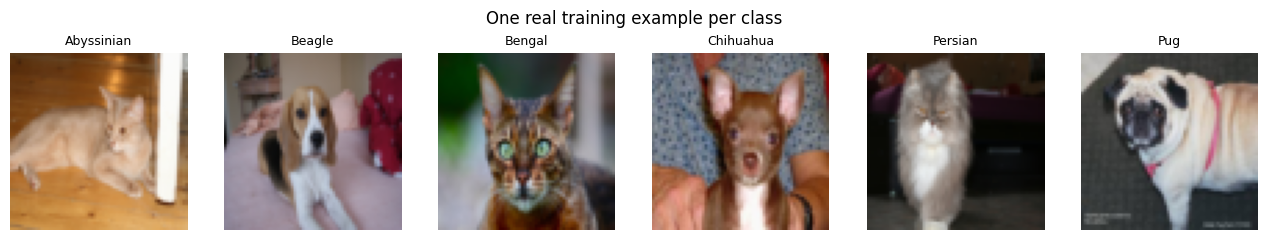

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

tfm_pretrained = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
tfm_scratch = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

pets_train_224 = OxfordIIITPet(root=DATA_DIR, split="trainval", transform=tfm_pretrained)
pets_test_224 = OxfordIIITPet(root=DATA_DIR, split="test", transform=tfm_pretrained)
pets_train_64 = OxfordIIITPet(root=DATA_DIR, split="trainval", transform=tfm_scratch)
pets_test_64 = OxfordIIITPet(root=DATA_DIR, split="test", transform=tfm_scratch)

def build_xy(dataset, idx_list, label_map):
    X = torch.stack([dataset[i][0] for i in idx_list])
    y = torch.tensor([label_map[dataset._labels[i]] for i in idx_list])
    return X, y

X_train_224, y_train_224 = build_xy(pets_train_224, train_idx, label_map)
X_test_224, y_test_224 = build_xy(pets_test_224, test_idx, label_map)
X_train_64, y_train_64 = build_xy(pets_train_64, train_idx, label_map)
X_test_64, y_test_64 = build_xy(pets_test_64, test_idx, label_map)

fig, axes = plt.subplots(1, 6, figsize=(13, 2.4))
for i, ax in enumerate(axes):
    img = X_train_64[y_train_64.tolist().index(i)].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(PET_CLASS_NAMES[chosen_classes[i]], fontsize=9)
    ax.axis("off")
plt.suptitle("One real training example per class")
plt.tight_layout()
plt.show()


### (a) Training a small CNN from scratch


In [9]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        def block(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, kernel_size=3, padding=1),
                nn.BatchNorm2d(c_out),
                nn.ReLU(),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(block(3, 16), block(16, 32), block(32, 64), block(64, 64))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.features(x)
        return self.fc(self.pool(x).flatten(1))


torch.manual_seed(0)
scratch_model = SmallCNN(n_classes=len(chosen_classes))
opt = torch.optim.Adam(scratch_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

N_EPOCHS_SCRATCH = 15
scratch_train_losses = []
t0 = time.time()
for epoch in range(N_EPOCHS_SCRATCH):
    perm = torch.randperm(len(X_train_64))
    epoch_loss, n_batches = 0.0, 0
    for start in range(0, len(X_train_64), 16):
        b = perm[start:start + 16]
        opt.zero_grad()
        out = scratch_model(X_train_64[b])
        loss = loss_fn(out, y_train_64[b])
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
        n_batches += 1
    scratch_train_losses.append(epoch_loss / n_batches)

print(f"From-scratch SmallCNN trained for {N_EPOCHS_SCRATCH} epochs in {time.time() - t0:.1f}s")

scratch_model.eval()
with torch.no_grad():
    train_acc_scratch = (scratch_model(X_train_64).argmax(1) == y_train_64).float().mean().item()
    test_acc_scratch = (scratch_model(X_test_64).argmax(1) == y_test_64).float().mean().item()
print(f"From-scratch SmallCNN -- train accuracy: {train_acc_scratch*100:.1f}%  |  "
      f"REAL held-out test accuracy: {test_acc_scratch*100:.1f}%")


From-scratch SmallCNN trained for 15 epochs in 9.9s


From-scratch SmallCNN -- train accuracy: 59.6%  |  REAL held-out test accuracy: 24.0%


### (b) Transfer learning: frozen ImageNet-pretrained ResNet-18 + new head

We load `resnet18` with real ImageNet weights, **freeze every backbone
parameter** (`requires_grad = False`), and replace the final 1000-way
classification layer with a fresh linear layer for our 6 classes. Because
the backbone is frozen, its output for a given image never changes across
epochs — so instead of re-running the (expensive) backbone forward pass
every epoch, we run it **once** to cache each image's 512-dimensional
feature vector, then train only the small linear head on those cached
features. This is the standard, practitioner-grade way to do frozen-
backbone feature-extraction transfer learning quickly.


In [10]:
weights = ResNet18_Weights.DEFAULT
backbone = resnet18(weights=weights)
n_features = backbone.fc.in_features           # 512 for resnet18
backbone.fc = nn.Identity()                     # strip the original 1000-way ImageNet head
backbone.eval()
for p in backbone.parameters():
    p.requires_grad = False

print(f"Loaded resnet18 with real ImageNet-pretrained weights ({weights}).")
print(f"Backbone frozen: {sum(p.numel() for p in backbone.parameters() if p.requires_grad)} trainable "
      f"backbone params (should be 0). Feature dimension: {n_features}.")

@torch.no_grad()
def extract_features(model, X, batch_size=16):
    feats = []
    for start in range(0, len(X), batch_size):
        feats.append(model(X[start:start + batch_size]))
    return torch.cat(feats, dim=0)

t0 = time.time()
feat_train = extract_features(backbone, X_train_224)
feat_test = extract_features(backbone, X_test_224)
print(f"Extracted frozen-backbone features for {len(feat_train)} train / {len(feat_test)} test "
      f"images in {time.time() - t0:.1f}s -- shapes: {tuple(feat_train.shape)}, {tuple(feat_test.shape)}")


Loaded resnet18 with real ImageNet-pretrained weights (ResNet18_Weights.IMAGENET1K_V1).
Backbone frozen: 0 trainable backbone params (should be 0). Feature dimension: 512.


Extracted frozen-backbone features for 240 train / 150 test images in 16.6s -- shapes: (240, 512), (150, 512)


In [11]:
torch.manual_seed(0)
head = nn.Linear(n_features, len(chosen_classes))
opt_head = torch.optim.Adam(head.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

N_EPOCHS_HEAD = 60
head_train_losses = []
t0 = time.time()
for epoch in range(N_EPOCHS_HEAD):
    perm = torch.randperm(len(feat_train))
    epoch_loss, n_batches = 0.0, 0
    for start in range(0, len(feat_train), 32):
        b = perm[start:start + 32]
        opt_head.zero_grad()
        out = head(feat_train[b])
        loss = loss_fn(out, y_train_224[b])
        loss.backward()
        opt_head.step()
        epoch_loss += loss.item()
        n_batches += 1
    head_train_losses.append(epoch_loss / n_batches)

print(f"Trained the new linear head for {N_EPOCHS_HEAD} epochs on cached features in {time.time() - t0:.2f}s")

head.eval()
with torch.no_grad():
    train_acc_transfer = (head(feat_train).argmax(1) == y_train_224).float().mean().item()
    test_acc_transfer = (head(feat_test).argmax(1) == y_test_224).float().mean().item()
print(f"Transfer learning (frozen resnet18 + new head) -- train accuracy: {train_acc_transfer*100:.1f}%  |  "
      f"REAL held-out test accuracy: {test_acc_transfer*100:.1f}%")


Trained the new linear head for 60 epochs on cached features in 0.65s
Transfer learning (frozen resnet18 + new head) -- train accuracy: 100.0%  |  REAL held-out test accuracy: 93.3%


### Head-to-head comparison


Model                                           Train acc    Test acc
---------------------------------------------------------------------
(a) SmallCNN, trained from scratch                  59.6%       24.0%
(b) resnet18, frozen + transfer-learned head       100.0%       93.3%


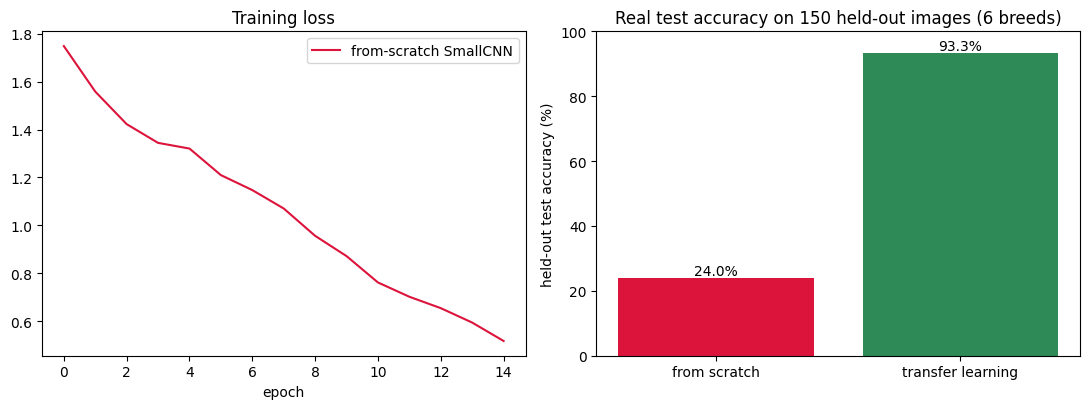

In [12]:
print(f"{'Model':45s}{'Train acc':>12s}{'Test acc':>12s}")
print("-" * 69)
print(f"{'(a) SmallCNN, trained from scratch':45s}{train_acc_scratch*100:11.1f}%{test_acc_scratch*100:11.1f}%")
print(f"{'(b) resnet18, frozen + transfer-learned head':45s}{train_acc_transfer*100:11.1f}%{test_acc_transfer*100:11.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(scratch_train_losses, label="from-scratch SmallCNN", color="crimson")
axes[0].set_title("Training loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

bars = axes[1].bar(["from scratch", "transfer learning"],
                    [test_acc_scratch * 100, test_acc_transfer * 100],
                    color=["crimson", "seagreen"])
axes[1].set_ylabel("held-out test accuracy (%)")
axes[1].set_title(f"Real test accuracy on {len(X_test_224)} held-out images ({len(chosen_classes)} breeds)")
axes[1].set_ylim(0, 100)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, h + 1, f"{h:.1f}%", ha="center")
plt.tight_layout()
plt.show()


These are real, measured numbers from the two runs above, on real held-out
photos the models never trained on. Whatever the exact gap turns out to be
on this run, the direction is the point: with only ~40 labeled images per
class, a small CNN starting from random weights has to learn *everything*
— edges, textures, shapes — from almost nothing, while the transfer-
learning model starts from features already tuned on 1.2M ImageNet photos
and only has to learn how to combine them for 6 new classes. That's the
entire practical case for transfer learning in one comparison.


## Use cases

**Transfer learning is the practical default whenever labeled data is
scarce relative to problem difficulty** — which describes most real
applied computer vision problems, since ImageNet-scale labeled datasets
are the exception, not the rule:

- **Medical imaging**: classifying or localizing findings in X-rays, CT/MRI
  slices, or dermatology photos, where labeled data requires expert
  clinician time and is inherently limited and expensive to collect.
- **Industrial and quality-control inspection**: detecting defects on a
  specific manufacturing line, where the "dataset" is however many labeled
  defect photos a factory has collected, often only hundreds.
- **Wildlife/ecological monitoring, satellite imagery, agriculture**: any
  domain-specific visual task where collecting and labeling millions of
  images isn't feasible.
- **Rapid prototyping**: even when more data *could* eventually be
  collected, transfer learning gives a strong baseline in hours instead of
  the days/weeks required to train a competitive CNN from scratch.

**Feature extraction vs. fine-tuning — a real, dataset-dependent choice:**

| Strategy | What's trained | Best when |
|---|---|---|
| **Frozen backbone + new head** (used above) | Only the final layer(s) | Small target dataset, target domain visually similar to ImageNet (natural photos) |
| **Partial fine-tuning** (unfreeze last few blocks) | Head + last N backbone layers | Medium-sized dataset, some domain shift from ImageNet |
| **Full fine-tuning** (unfreeze everything) | The entire network | Larger target dataset, and/or the target domain differs substantially from natural photos |

The intuition: early CNN layers learn very generic features (edges,
color blobs, textures) that transfer well across almost any visual domain;
later layers learn increasingly task-specific, ImageNet-specific
combinations of those features. A small dataset can't reliably re-train
millions of late-layer parameters without overfitting, so freezing them
(or only partially unfreezing) acts as a strong, free regularizer — this is
the same overfitting-vs-capacity tradeoff from the perceptron tutorial's
limitations section, applied to *how much of a pretrained network* you
allow gradient descent to touch.


## Limitations & debates

- **Domain gap: transfer learning is not magic when the target domain looks
  nothing like ImageNet.** ImageNet is overwhelmingly natural photos of
  everyday objects and animals, taken by people, at roughly human-eye
  scale. Raghu, Zhang, Kleinberg & Bengio (2019, *"Transfusion: Understanding
  Transfer Learning for Medical Imaging"*) is a well-known, documented study
  showing that ImageNet-pretrained features transfer *much* less cleanly to
  medical imaging domains (chest X-rays, retinal photos): standard-sized
  pretrained architectures didn't reliably outperform smaller, simpler
  models trained from scratch on the medical task, and mostly helped by
  speeding up convergence rather than by transferring genuinely useful
  visual features. The same caution applies to other domains far from
  natural photography — satellite/aerial imagery, microscopy, thermal
  imaging — where low-level ImageNet features (tuned for the statistics of
  everyday photos) may simply not be the right building blocks. Always
  validate transfer learning against a from-scratch or domain-pretrained
  baseline on the actual target domain, rather than assuming it helps.
- **"Deeper is always better" is not true — diminishing returns and real
  compute cost.** Beyond a certain depth, additional layers yield
  shrinking accuracy gains for growing compute/memory cost, and very deep
  networks are markedly more expensive to train and serve. Architecture
  search since ResNet has spent as much effort on *efficiency* (MobileNet,
  EfficientNet — getting more accuracy per FLOP) as on raw depth, which is
  itself evidence that "just make it deeper" stopped being the dominant
  strategy once the degradation problem was solved.
- **Training these architectures from scratch at full ImageNet scale is
  genuinely expensive, which is precisely why transfer learning dominates
  outside large labs.** The original ResNet paper trained on 8 GPUs for
  multiple weeks; more recent reported figures for training a ResNet-50
  from scratch on ImageNet are on the order of tens of GPU-hours on modern
  hardware (still meaningfully out of reach for a laptop or a single
  consumer GPU in reasonable time) — and that's before any hyperparameter
  search. This tutorial's own from-scratch CNN above trains on 240 images
  in under a minute on a CPU precisely *because* it's tiny and the problem
  is small; scaling that naively to ImageNet-level accuracy is not a matter
  of just waiting longer with the same code.
- **A frozen backbone can underperform if the target task needs features
  the backbone never learned to represent.** If none of ImageNet's 1000
  classes involve anything like the discriminative detail the target task
  needs (e.g. subtle texture differences that matter for a specific defect
  but never mattered for distinguishing dog breeds from staplers),
  freezing may leave meaningful accuracy on the table versus fine-tuning —
  the frozen vs. fine-tune choice in the table above is a real, dataset-
  dependent tradeoff, not a default that's always correct.
- **Batch normalization's statistics complicate fine-tuning.** When
  partially or fully fine-tuning a pretrained network (rather than fully
  freezing it), BatchNorm layers' running statistics were computed on
  ImageNet's data distribution; a small fine-tuning batch size or a very
  different target-domain distribution can make those statistics a poor
  fit, a known practical gotcha that sometimes requires freezing BatchNorm
  layers specifically even while fine-tuning the surrounding conv weights.


## References

- He, K., Zhang, X., Ren, S., & Sun, J. (2015). *Deep Residual Learning for
  Image Recognition.* arXiv:1512.03385 (CVPR 2016). The residual block, the
  degradation problem, and ResNet.
- Simonyan, K., & Zisserman, A. (2014). *Very Deep Convolutional Networks
  for Large-Scale Image Recognition.* arXiv:1409.1556. VGG.
- Szegedy, C. et al. (2014). *Going Deeper with Convolutions.*
  arXiv:1409.4842. GoogLeNet / the Inception module.
- Deng, J., Dong, W., Socher, R., Li, L.-J., Li, K., & Fei-Fei, L. (2009).
  *ImageNet: A Large-Scale Hierarchical Image Database.* CVPR. The
  pretraining dataset behind every `torchvision.models` ImageNet checkpoint
  used in this tutorial.
- Raghu, M., Zhang, C., Kleinberg, J., & Bengio, S. (2019). *Transfusion:
  Understanding Transfer Learning for Medical Imaging.* NeurIPS. The
  documented medical-imaging domain-gap finding cited in Limitations &
  debates.
- Parkhi, O. M., Vedaldi, A., Zisserman, A., & Jawahar, C. V. (2012). *Cats
  and Dogs.* CVPR. The Oxford-IIIT Pet dataset used throughout this
  tutorial's implementation.
- Rumelhart, Hinton & Williams (1986), cited in `perceptron-and-
  backpropagation` — the vanishing-gradient mechanism this tutorial's
  gradient-flow argument builds on directly.
- `torchvision.models` documentation,
  [pytorch.org/vision/stable/models.html](https://pytorch.org/vision/stable/models.html)
  — pretrained `resnet18` weights and the `OxfordIIITPet` dataset loader
  used in this tutorial's implementation.
